In [7]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
import seaborn as sns

$$

\rho_{\text{th}}
=
\sum_{n=0}^{\infty}
\frac{\bar n^n}{(1+\bar n)^{n+1}}
|n\rangle\langle n|$$
$$\Delta X^2 = \Delta P^2 = \bar n + \frac12$$


$$D(\alpha)|n\rangle
=
\frac{
(a^\dagger-\alpha^*)^n
}{
\sqrt{n!}
}
|\alpha\rangle$$
- Since displacement operator is unitary, we can think the transformed kets are also orthagonal, then we can write the  $\rho$ in terms of these transformed kets.


In [8]:
N=40
alpha=1+1j

start = -10
end = 10
x=np.linspace(start,end,200)

In [9]:
def displacedRho(alpha,rhoThermal):
    disOptr=qt.displace(N=N,alpha=alpha)
    newRho=disOptr@rhoThermal@disOptr.dag()
    return newRho

In [10]:
def spreadFunction(alpha=0):
    displaced=""
    l = 0
    fig = plt.figure(figsize=(12,10))
    nbarlist=[1,2,3,4]
    ax1=fig.add_subplot(2,2,1)
    ax2=fig.add_subplot(2,2,2)
    ax3=fig.add_subplot(2,2,3)
    ax4=fig.add_subplot(2,2,4)
    axlist=[ax1,ax2,ax3,ax4]
    for nbar in nbarlist:
        ax=axlist[l]
        rhoThermal=qt.thermal_dm(N=N,n=nbar)
        if(alpha!=0):
            displaced="thermal state in displaced fock basis "
            rhoThermal=displacedRho(alpha=alpha,rhoThermal=rhoThermal)
        else:
            displaced="thermal state in fock basis"
        wigner=qt.wigner(rhoThermal,x,x)
        tickLabels=np.linspace(start,end,11)
        tick_positions = np.linspace(0, 199, 11)
        heat = sns.heatmap(wigner,fmt=".2f",ax=ax)
        ax.set_xticks(tick_positions,tickLabels)
        ax.set_yticks(tick_positions,tickLabels)
        ax.set_title(f"$\\bar n = {nbar}$",)
        ax.set_xlabel("X",fontsize=10,fontweight="bold")
        ax.set_ylabel("P",fontsize=10,fontweight="bold")
        l+=1
    plt.suptitle(f"Function for {displaced} ",fontsize=13,fontweight="bold")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


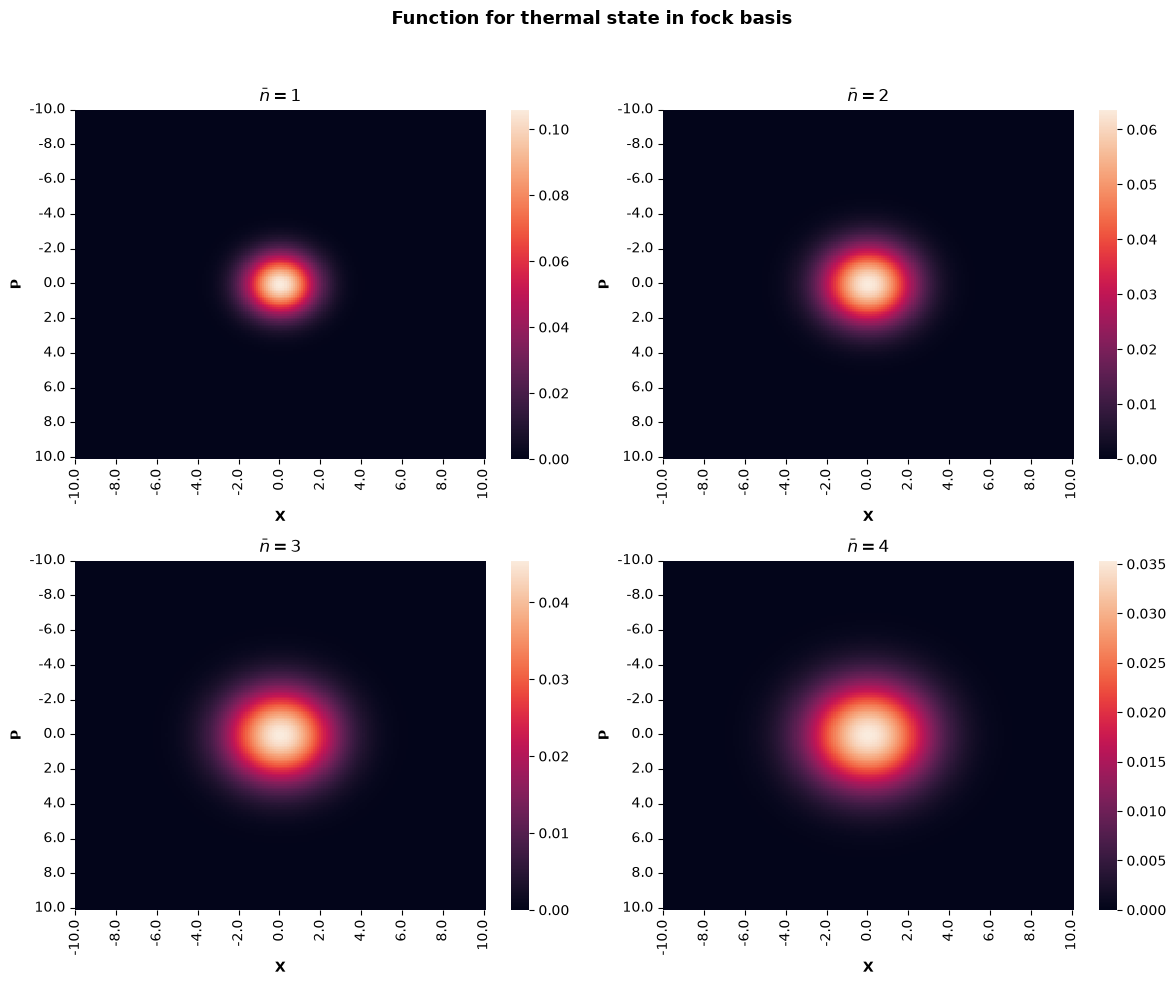

In [11]:
spreadFunction(alpha=0)

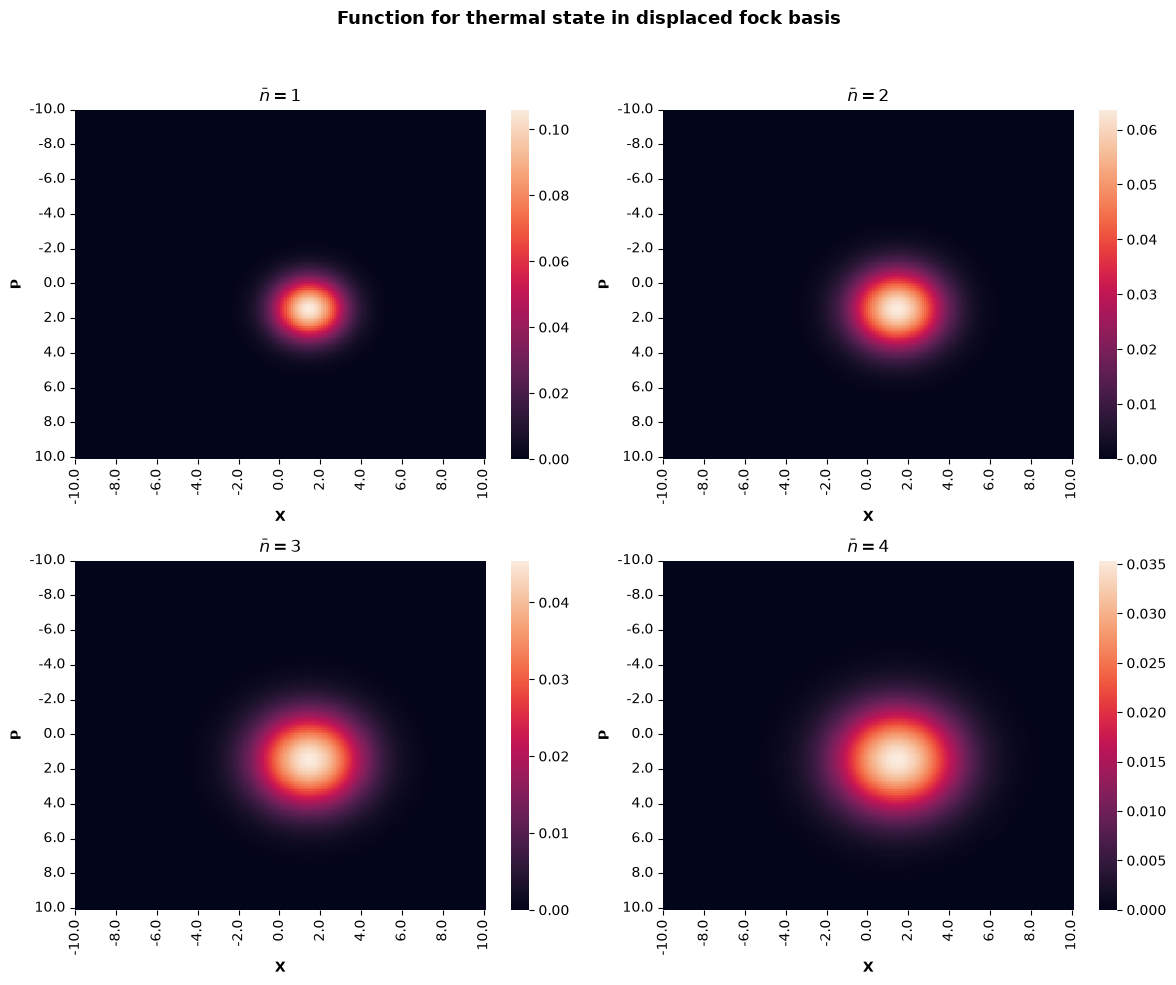

In [12]:
spreadFunction(alpha=alpha)

###  When we change the thermal state from fock basis to displaced fock basis:
- Uncertainity in phase space - Unchanged
- Maximum Height - Unchanged
- The uncertainity and maximum height will affect normalization, and we usually integrate from $-\infty \to \infty$ so only translation in phase space is allowed.